In [20]:
from pathlib import Path
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.simplefilter("ignore")

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]
project_root = next(
    (path for path in candidate_roots if (path / "src").exists() and (path / "data").exists()),
    None,
)
if project_root is None:
    raise RuntimeError("Could not locate project root from the current working directory.")

src_dir = project_root / "src"
fig_dir = project_root / "results" / "fig"
data_dir = project_root / "data"

sys.path.insert(0, str(src_dir))

from func_data_build import build_dataset
fig_dir.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename):
    fig.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")

data_origin = build_dataset(data_dir)

# Period (1982-2012)

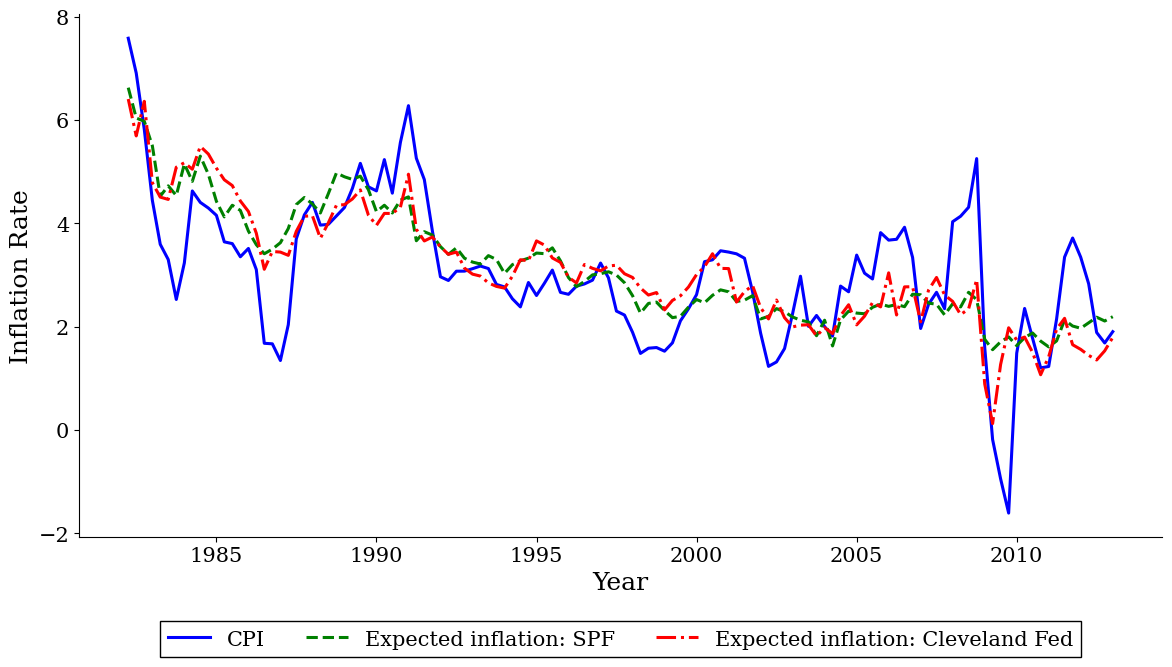

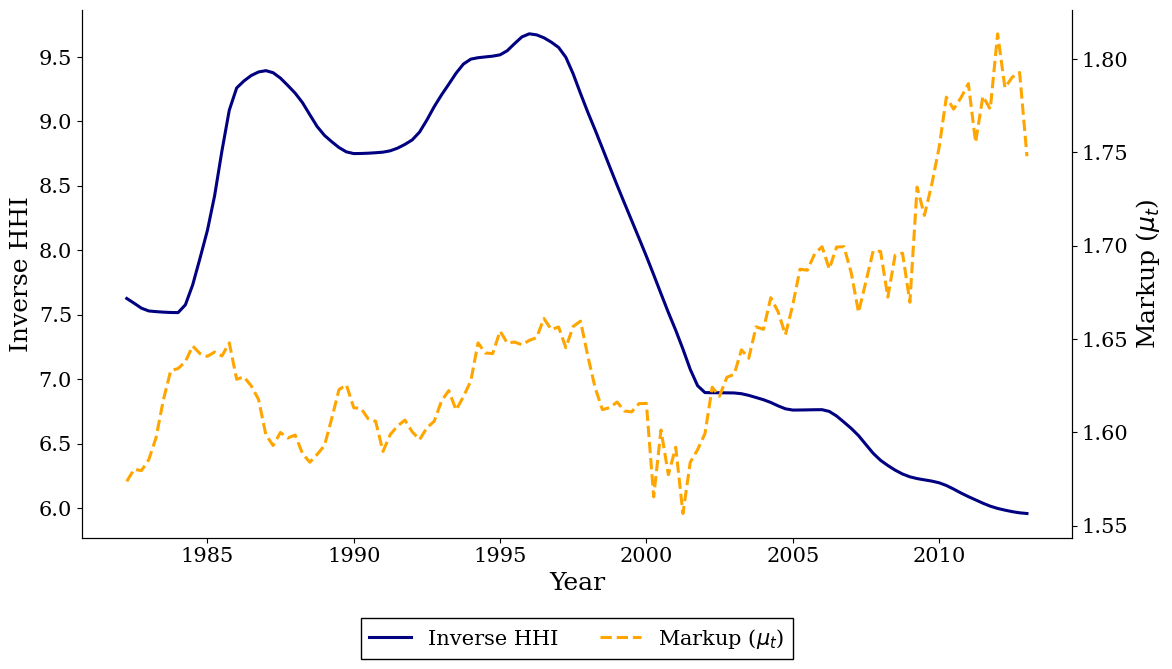

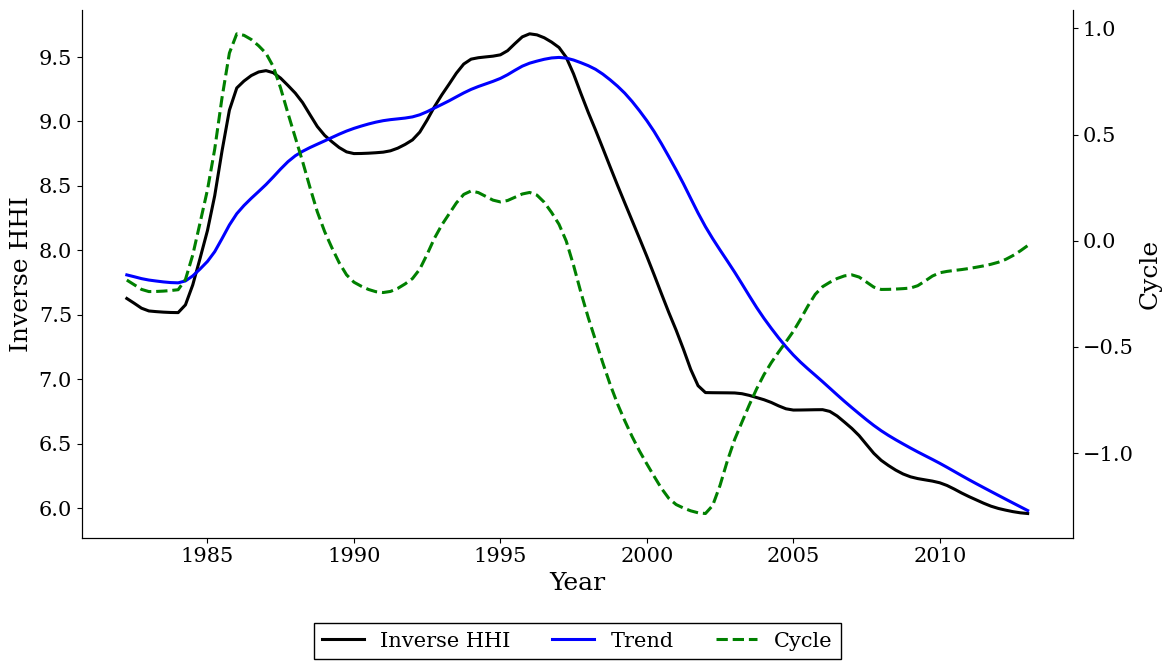

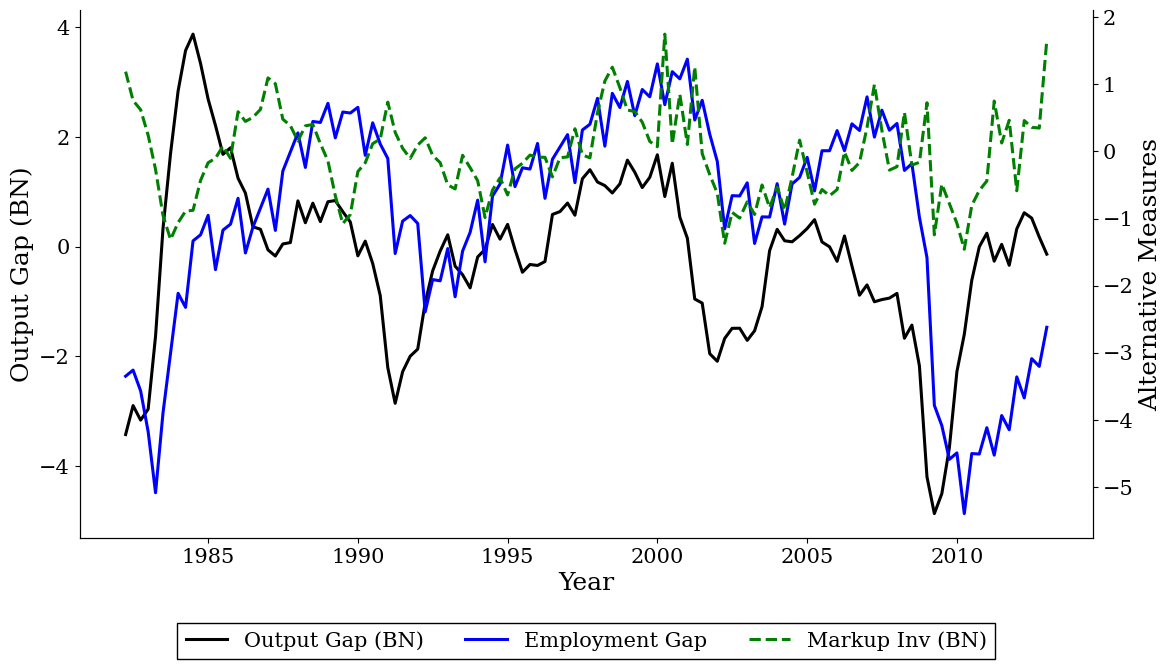

In [21]:

data = data_origin.loc["1982-01-01":"2012-12-31"].copy()
data["DATE"] = pd.to_datetime(data.index)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})
fig, ax1 = plt.subplots(figsize=(12, 7))
line1, = ax1.plot(
    data["DATE"],
    data["pi_cpi"],
    color="blue",
    linewidth=2.2,
    label="CPI"
)
line2, = ax1.plot(
    data["DATE"],
    data["Epi_spf_cpi"],
    color="green",
    linewidth=2.2,
    linestyle="--",
    label="Expected inflation: SPF"
)
line3, = ax1.plot(
    data["DATE"],
    data["Epi"],
    color="red",
    linewidth=2.2,
    linestyle="-.",
    label="Expected inflation: Cleveland Fed"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Inflation Rate")
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(
    [line1, line2, line3],
    [line.get_label() for line in [line1, line2, line3]],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1
)
fig.tight_layout()
save_figure(fig, "inflation_expectations.png")
plt.show()

fig, ax_left = plt.subplots(figsize=(12, 7))
ax_right = ax_left.twinx()
line1, = ax_left.plot(
    data["DATE"],
    data["N_Gustavo"],
    color="navy",
    linewidth=2.2,
    label="Inverse HHI"
)
line2, = ax_right.plot(
    data["DATE"],
    data["markup"],
    color="orange",
    linewidth=2.2,
    linestyle="--",
    label=r"Markup ($\mu_t$)"
)
ax_left.set_xlabel("Year")
ax_left.set_ylabel("Inverse HHI")
ax_right.set_ylabel(r"Markup ($\mu_t$)")
ax_left.xaxis.set_major_locator(mdates.YearLocator(5))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_left.spines["top"].set_visible(False)
ax_right.spines["top"].set_visible(False)
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax_left.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1
)
fig.tight_layout()
save_figure(fig, "inverse_hhi_markup.png")
plt.show()


fig, ax_left = plt.subplots(figsize=(12, 7))
ax_right = ax_left.twinx()

line1, = ax_left.plot(
    data["DATE"],
    data["N_Gustavo"],
    color="black",
    linewidth=2.2,
    label="Inverse HHI"
)

line2, = ax_left.plot(
    data["DATE"],
    data["N_Gustavo_BN_trend"],
    color="blue",
    linewidth=2.2,
    label="Trend"
)

line3, = ax_right.plot(
    data["DATE"],
    data["N_Gustavo_BN_cycle"],
    color="green",
    linewidth=2.2,
    linestyle="--",
    label="Cycle"
)

ax_left.set_xlabel("Year")
ax_left.set_ylabel("Inverse HHI")
ax_right.set_ylabel("Cycle")

ax_left.xaxis.set_major_locator(mdates.YearLocator(5))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_left.spines["top"].set_visible(False)
ax_right.spines["top"].set_visible(False)

lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax_left.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1
)

fig.tight_layout()
save_figure(fig, "inverse_hhi_trend_cycle.png")
plt.show()

fig, ax_left = plt.subplots(figsize=(12, 7))
ax_right = ax_left.twinx()

line1, = ax_left.plot(
    data["DATE"],
    data["output_gap_BN"],
    color="black",
    linewidth=2.2,
    label="Output Gap (BN)"
)

line2, = ax_right.plot(
    data["DATE"],
    data["unemp_gap"],
    color="blue",
    linewidth=2.2,
    label="Employment Gap"
)

line3, = ax_right.plot(
    data["DATE"],
    data["markup_BN_inv"],
    color="green",
    linewidth=2.2,
    linestyle="--",
    label="Markup Inv (BN)"
)

ax_left.set_xlabel("Year")
ax_left.set_ylabel("Output Gap (BN)")
ax_right.set_ylabel("Alternative Measures")

ax_left.xaxis.set_major_locator(mdates.YearLocator(5))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_left.spines["top"].set_visible(False)
ax_right.spines["top"].set_visible(False)

lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax_left.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1
)

fig.tight_layout()
save_figure(fig, "gap_comparison.png")
plt.show()

# Period (1988-2017)

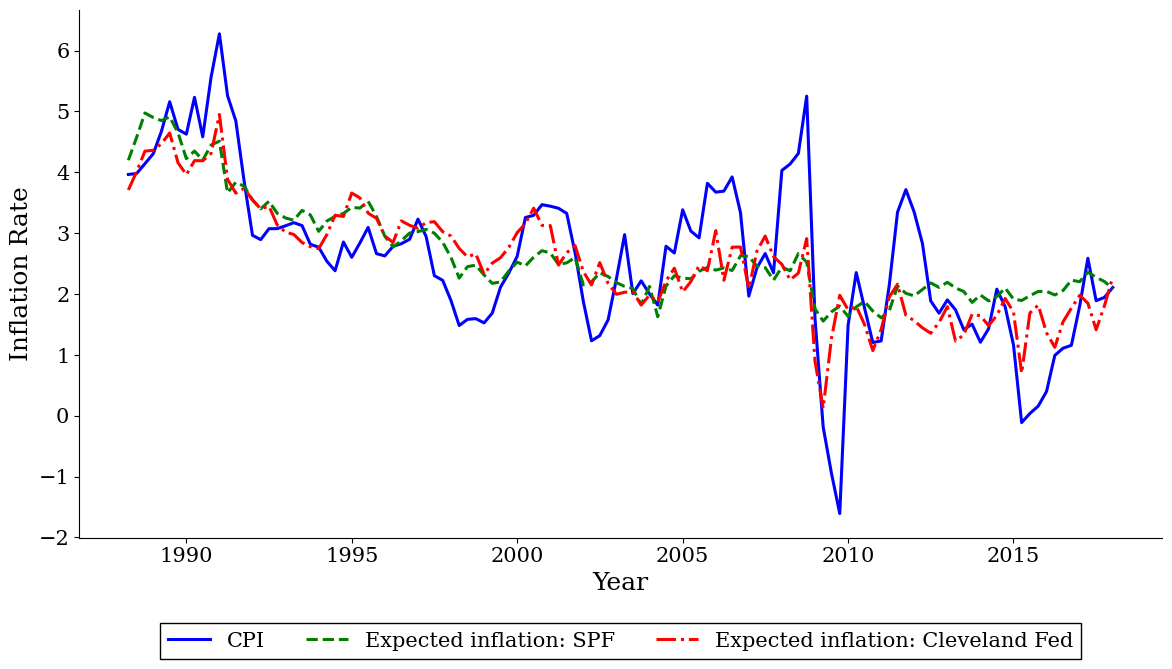

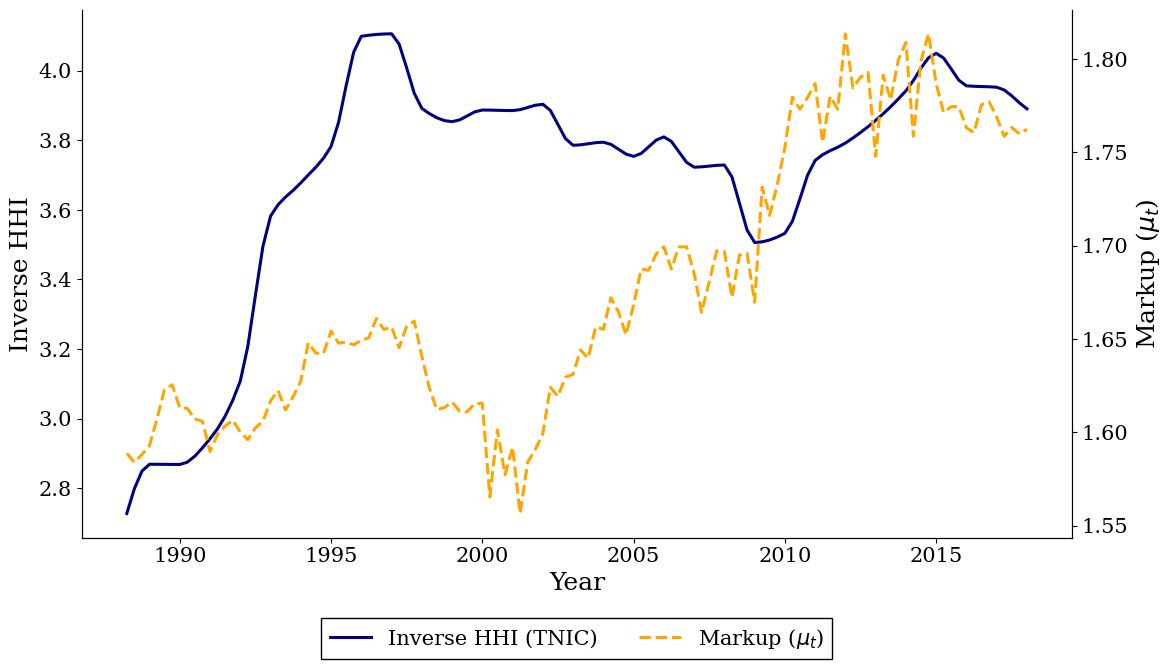

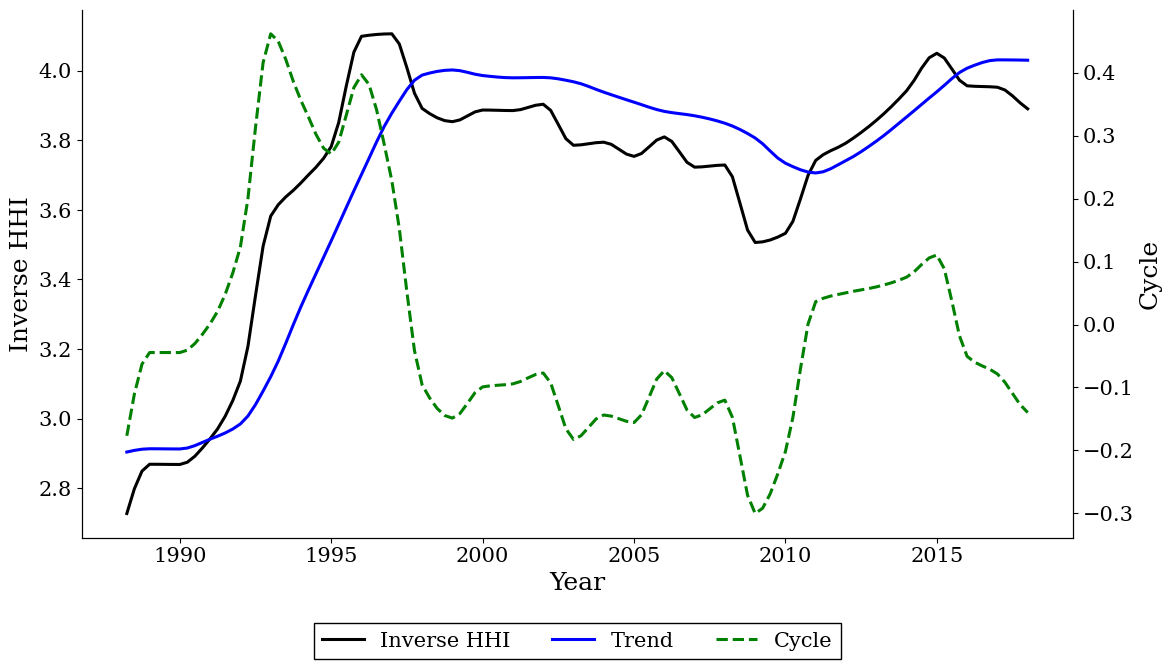

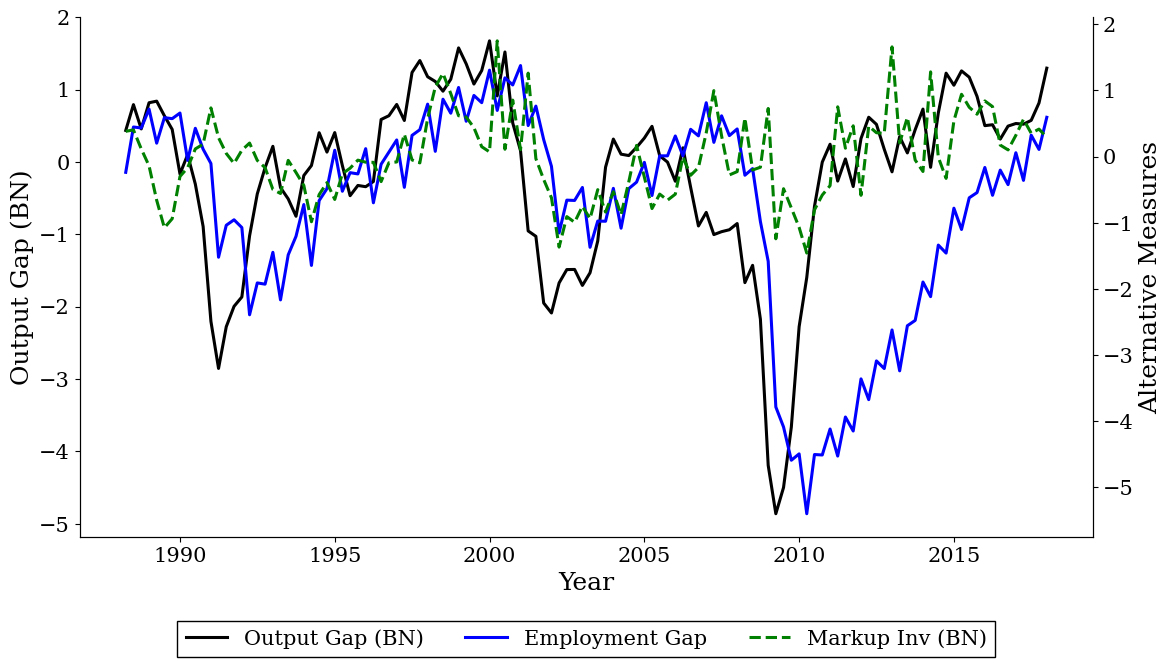

In [22]:
data = data_origin.loc["1988-03-31":"2017-12-31"].copy()
data["DATE"] = pd.to_datetime(data.index)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})
fig, ax1 = plt.subplots(figsize=(12, 7))
line1, = ax1.plot(
    data["DATE"],
    data["pi_cpi"],
    color="blue",
    linewidth=2.2,
    label="CPI"
)
line2, = ax1.plot(
    data["DATE"],
    data["Epi_spf_cpi"],
    color="green",
    linewidth=2.2,
    linestyle="--",
    label="Expected inflation: SPF"
)
line3, = ax1.plot(
    data["DATE"],
    data["Epi"],
    color="red",
    linewidth=2.2,
    linestyle="-.",
    label="Expected inflation: Cleveland Fed"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Inflation Rate")
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(
    [line1, line2, line3],
    [line.get_label() for line in [line1, line2, line3]],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1
)
fig.tight_layout()
save_figure(fig, "inflation_expectations.png")
plt.show()

fig, ax_left = plt.subplots(figsize=(12, 7))
ax_right = ax_left.twinx()
line1, = ax_left.plot(
    data["DATE"],
    data["N_TNIC"],
    color="navy",
    linewidth=2.2,
    label="Inverse HHI (TNIC)"
)
line2, = ax_right.plot(
    data["DATE"],
    data["markup"],
    color="orange",
    linewidth=2.2,
    linestyle="--",
    label=r"Markup ($\mu_t$)"
)
ax_left.set_xlabel("Year")
ax_left.set_ylabel("Inverse HHI")
ax_right.set_ylabel(r"Markup ($\mu_t$)")
ax_left.xaxis.set_major_locator(mdates.YearLocator(5))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_left.spines["top"].set_visible(False)
ax_right.spines["top"].set_visible(False)
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax_left.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1
)
fig.tight_layout()
save_figure(fig, "inverse_hhi_markup.png")
plt.show()

fig, ax_left = plt.subplots(figsize=(12, 7))
ax_right = ax_left.twinx()

line1, = ax_left.plot(
    data["DATE"],
    data["N_TNIC"],
    color="black",
    linewidth=2.2,
    label="Inverse HHI"
)

line2, = ax_left.plot(
    data["DATE"],
    data["N_TNIC_BN_trend"],
    color="blue",
    linewidth=2.2,
    label="Trend"
)

line3, = ax_right.plot(
    data["DATE"],
    data["N_TNIC_BN_cycle"],
    color="green",
    linewidth=2.2,
    linestyle="--",
    label="Cycle"
)

ax_left.set_xlabel("Year")
ax_left.set_ylabel("Inverse HHI")
ax_right.set_ylabel("Cycle")

ax_left.xaxis.set_major_locator(mdates.YearLocator(5))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_left.spines["top"].set_visible(False)
ax_right.spines["top"].set_visible(False)

lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax_left.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1
)

fig.tight_layout()
save_figure(fig, "inverse_hhi_trend_cycle.png")
plt.show()


fig, ax_left = plt.subplots(figsize=(12, 7))
ax_right = ax_left.twinx()

line1, = ax_left.plot(
    data["DATE"],
    data["output_gap_BN"],
    color="black",
    linewidth=2.2,
    label="Output Gap (BN)"
)

line2, = ax_right.plot(
    data["DATE"],
    data["unemp_gap"],
    color="blue",
    linewidth=2.2,
    label="Employment Gap"
)

line3, = ax_right.plot(
    data["DATE"],
    data["markup_BN_inv"],
    color="green",
    linewidth=2.2,
    linestyle="--",
    label="Markup Inv (BN)"
)

ax_left.set_xlabel("Year")
ax_left.set_ylabel("Output Gap (BN)")
ax_right.set_ylabel("Alternative Measures")

ax_left.xaxis.set_major_locator(mdates.YearLocator(5))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_left.spines["top"].set_visible(False)
ax_right.spines["top"].set_visible(False)

lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax_left.legend(
    lines,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1
)

fig.tight_layout()
save_figure(fig, "gap_comparison.png")
plt.show()